# Data Fusion Architectures - IMU Indoor Navigation

**Authors:** Cedric Busman  & Ahamed al Wasi

This notebook documents the implemented IMU localization pipeline, the sensor-fusion architecture choices, the common representational format, the spatial alignment to a floorplan PDF, the required linear Kalman filter analysis, and the comparison between the Discrete Bayes filter and the Particle filter.

In [10]:
from pathlib import Path
import pandas as pd
import yaml
from IPython.display import Markdown, Image, display

ROOT = Path.cwd()
if not (ROOT / "config").exists():
    ROOT = Path.cwd() / "IMU assignment"

CONFIG = ROOT / "config"
DATA = ROOT / "data"
SRC = ROOT / "src"
OUT = DATA / "experiments" / "outputs"

with open(CONFIG / "system_config.yaml", "r", encoding="utf-8") as f:
    system_cfg = yaml.safe_load(f)
with open(CONFIG / "dsms_config.yaml", "r", encoding="utf-8") as f:
    dsms_cfg = yaml.safe_load(f)

final_summary = pd.read_csv(OUT / "final_results_summary.csv")
grouped_summary = pd.read_csv(OUT / "final_results_grouped_summary.csv")
kalman_summary = pd.read_csv(OUT / "kalman_analysis" / "kalman_first_runs_summary.csv")

final_summary.head()

,model,n_steps,walkable_ratio,path_length_m,runtime_s,runtime_ms_per_step,mean_neff,final_x_m,final_y_m,group,run_name,summary_file
0,particle,16.0,0.93750,9.537706,0.127547,7.971681,2735.430567,4.691144,6.655170,180Turn,log_turn180_1,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
1,discrete_bayes,16.0,0.93750,9.129097,0.047782,2.986375,62.437500,4.417610,6.389986,180Turn,log_turn180_1,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
2,particle,11.0,1.00000,6.477968,0.112466,10.224173,2609.731213,4.268882,4.851437,180Turn,log_turn180_2,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
3,discrete_bayes,11.0,1.00000,5.753036,0.035149,3.195364,66.909091,4.710106,5.289570,180Turn,log_turn180_2,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
4,discrete_bayes,13.5,0.96875,7.441067,0.041465,3.090869,64.673295,4.563858,5.839778,outputs,final_results_grouped,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...


## 1. Assignment mapping

This submission covers the following items:

- implementation of a **Bayes-based localization method**
- implementation of a **Particle filter**
- inclusion of **a linear Kalman filter**
- clear indication of where the **Bayesian rules** are implemented in code
- discussion of **priors, likelihoods, alignment, interfaces, and error propagation**

The localization comparison is intentionally centered on the **Discrete Bayes filter** and the **Particle filter**. The **linear Kalman filter** is used as a sensor-level smoothing method on gyroscope data, not as the final map-based localization model.

## 2. System architecture analysis

### 2.1 Centralized vs. decentralized
The IMU pipeline is implemented as a **centralized architecture**. Sensor logs, floorplan data, and localization logic are processed by one runtime on the Raspberry Pi or one offline runner. This keeps synchronization and debugging simple, which is appropriate for a single pedestrian localization problem.

### 2.2 Fusion level
The system mainly operates at **state-estimation level**. Raw IMU measurements are first converted into step events and heading changes. Those are then fused with the static floorplan probability density function to estimate the pedestrian state `(x, y, heading)`.

### 2.3 Cascade vs. parallel
The design is a **cascade architecture**. A sensor-level preprocessing stage produces heading changes and step events. Those outputs are then passed to the higher-level Bayes or Particle filter. The Kalman filter is therefore not the final localization stage; it is a lower-level denoising component in the overall chain.

### 2.4 Why this architecture fits the assignment
This separation makes the pipeline easier to explain and defend:

1. sensor acquisition and event extraction stay modular,
2. map-based Bayesian inference is isolated in dedicated filter classes,
3. the linear Kalman filter can be analyzed separately without confusing it with the final localization comparison.

## 3. Common representational format

The code uses a common event format for both localization models. Each step event is converted to a record containing at least:

- `timestamp`
- `dt`
- `heading_change`
- `step_length_m`

The output of each filter is logged in a shared run format with:

- `step_idx`
- `timestamp`
- `dt`
- `heading_change_rad`
- `heading_rad`
- `step_length_m`
- `x_m`, `y_m`
- `var_x`, `var_y`
- `neff`
- `map_probability`
- `walkable`

This common format is important because it allows the same experiment runner in `src/main.py` to call both filters and compare them fairly.

In [19]:
pd.DataFrame([system_cfg["motion_model"], system_cfg["particle_filter"], system_cfg["bayes_filter"]],
             index=["motion_model", "particle_filter", "bayes_filter"]).T.fillna("")

,motion_model,particle_filter,bayes_filter
heading_noise_std_rad,0.03,,
step_length_std_m,0.03,,
forward_bias_std_rad,0.08,,
directional_persistence,0.98,,
impossible_state_penalty,0.0,,
turn_gain,1.0,,
n_particles,,3000.0,
resample_threshold_ratio,,0.6,
resample_method,,systematic,
grid_resolution_xy_m,,,0.25


## 4. Spatial alignment and normalization

A key improvement in this implementation is that the floor plan is no longer treated as a visual reference only. Instead, it is incorporated directly into the localization process as a **static probability density function (PDF)** and used during the filter updates.

### 4.1 Floorplan PDF
The floor plan is stored as a rasterized map in `data/floor_plans/house_floorplan_pdf.pkl`. Each cell contains a walkability probability. Cells corresponding to valid corridors and rooms receive high probability, while walls and other invalid regions are assigned very low probability.

### 4.2 Spatial alignment
The localization state is defined in the same metric reference frame as the floor plan:

- position in meters: `(x, y)`
- heading in radians
- conversion between metric coordinates and floorplan cells handled by `floor_map.py`

This is the main spatial alignment step: motion is predicted in metric space, and the resulting state is evaluated against the floorplan PDF in that same coordinate system.

### 4.3 Normalization
After applying the motion model and the floorplan constraint, both localization methods normalize their belief representation:

- the **Discrete Bayes filter** normalizes the full belief grid
- the **Particle filter** normalizes the particle weights

This normalization is necessary because the floorplan likelihood is applied as a multiplicative Bayesian factor.

### 4.4 Quantifying alignment quality
To verify that the map constraint is functioning in practice, the saved output includes:

- `map_probability`
- `walkable`
- `walkable_ratio` per run

These values provide a direct check of whether the estimated trajectory remains inside plausible walkable regions of the building.


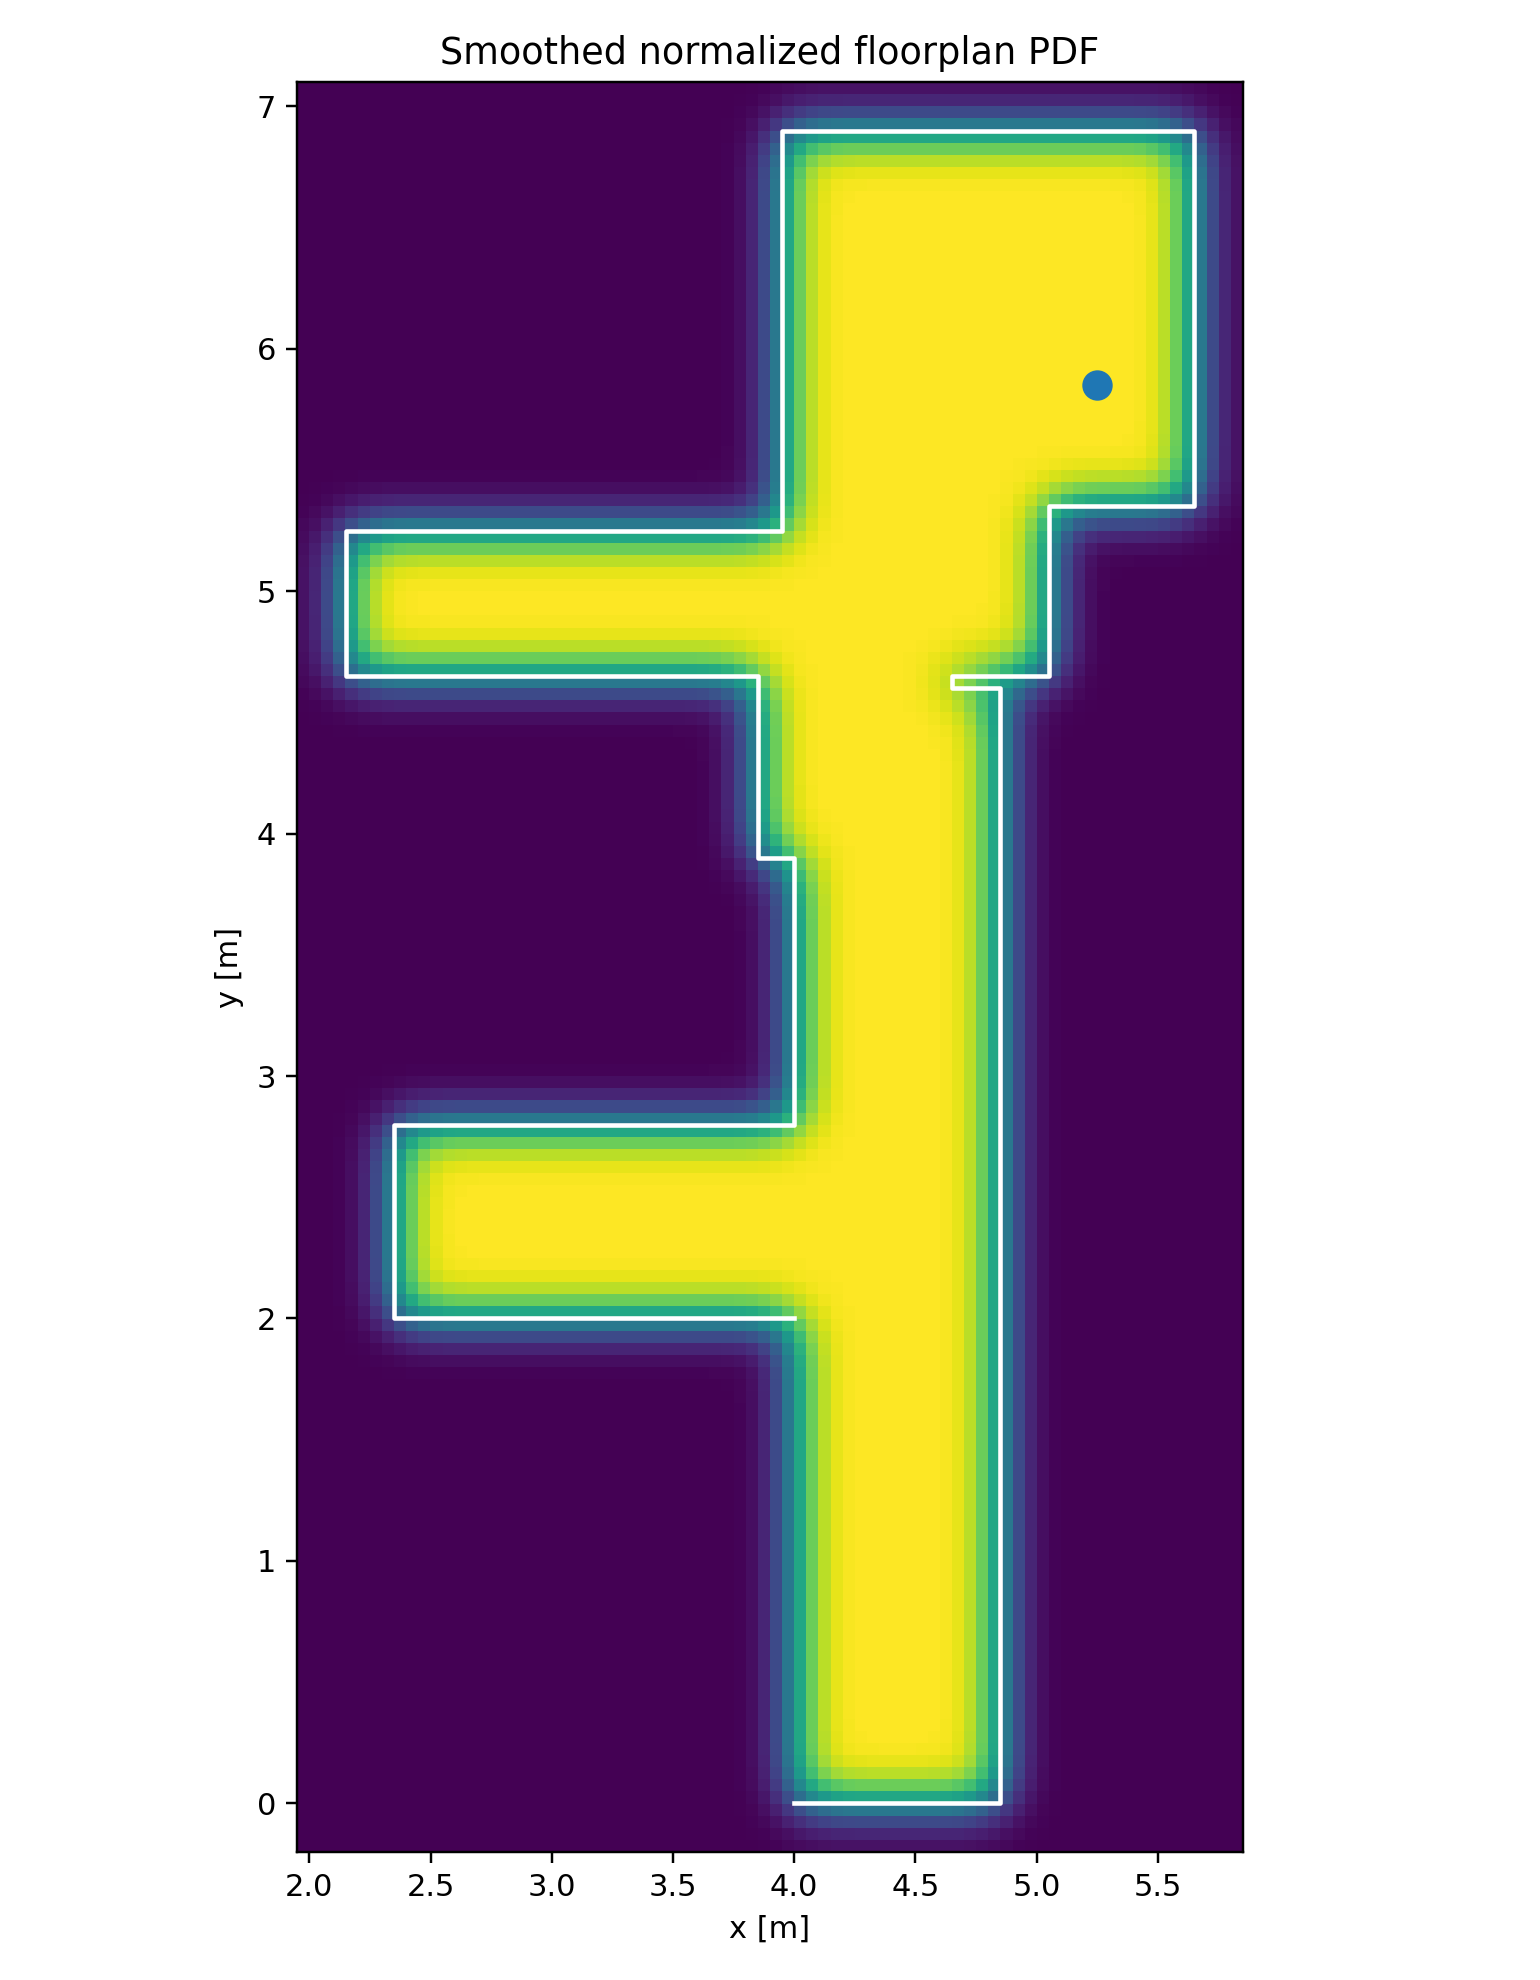

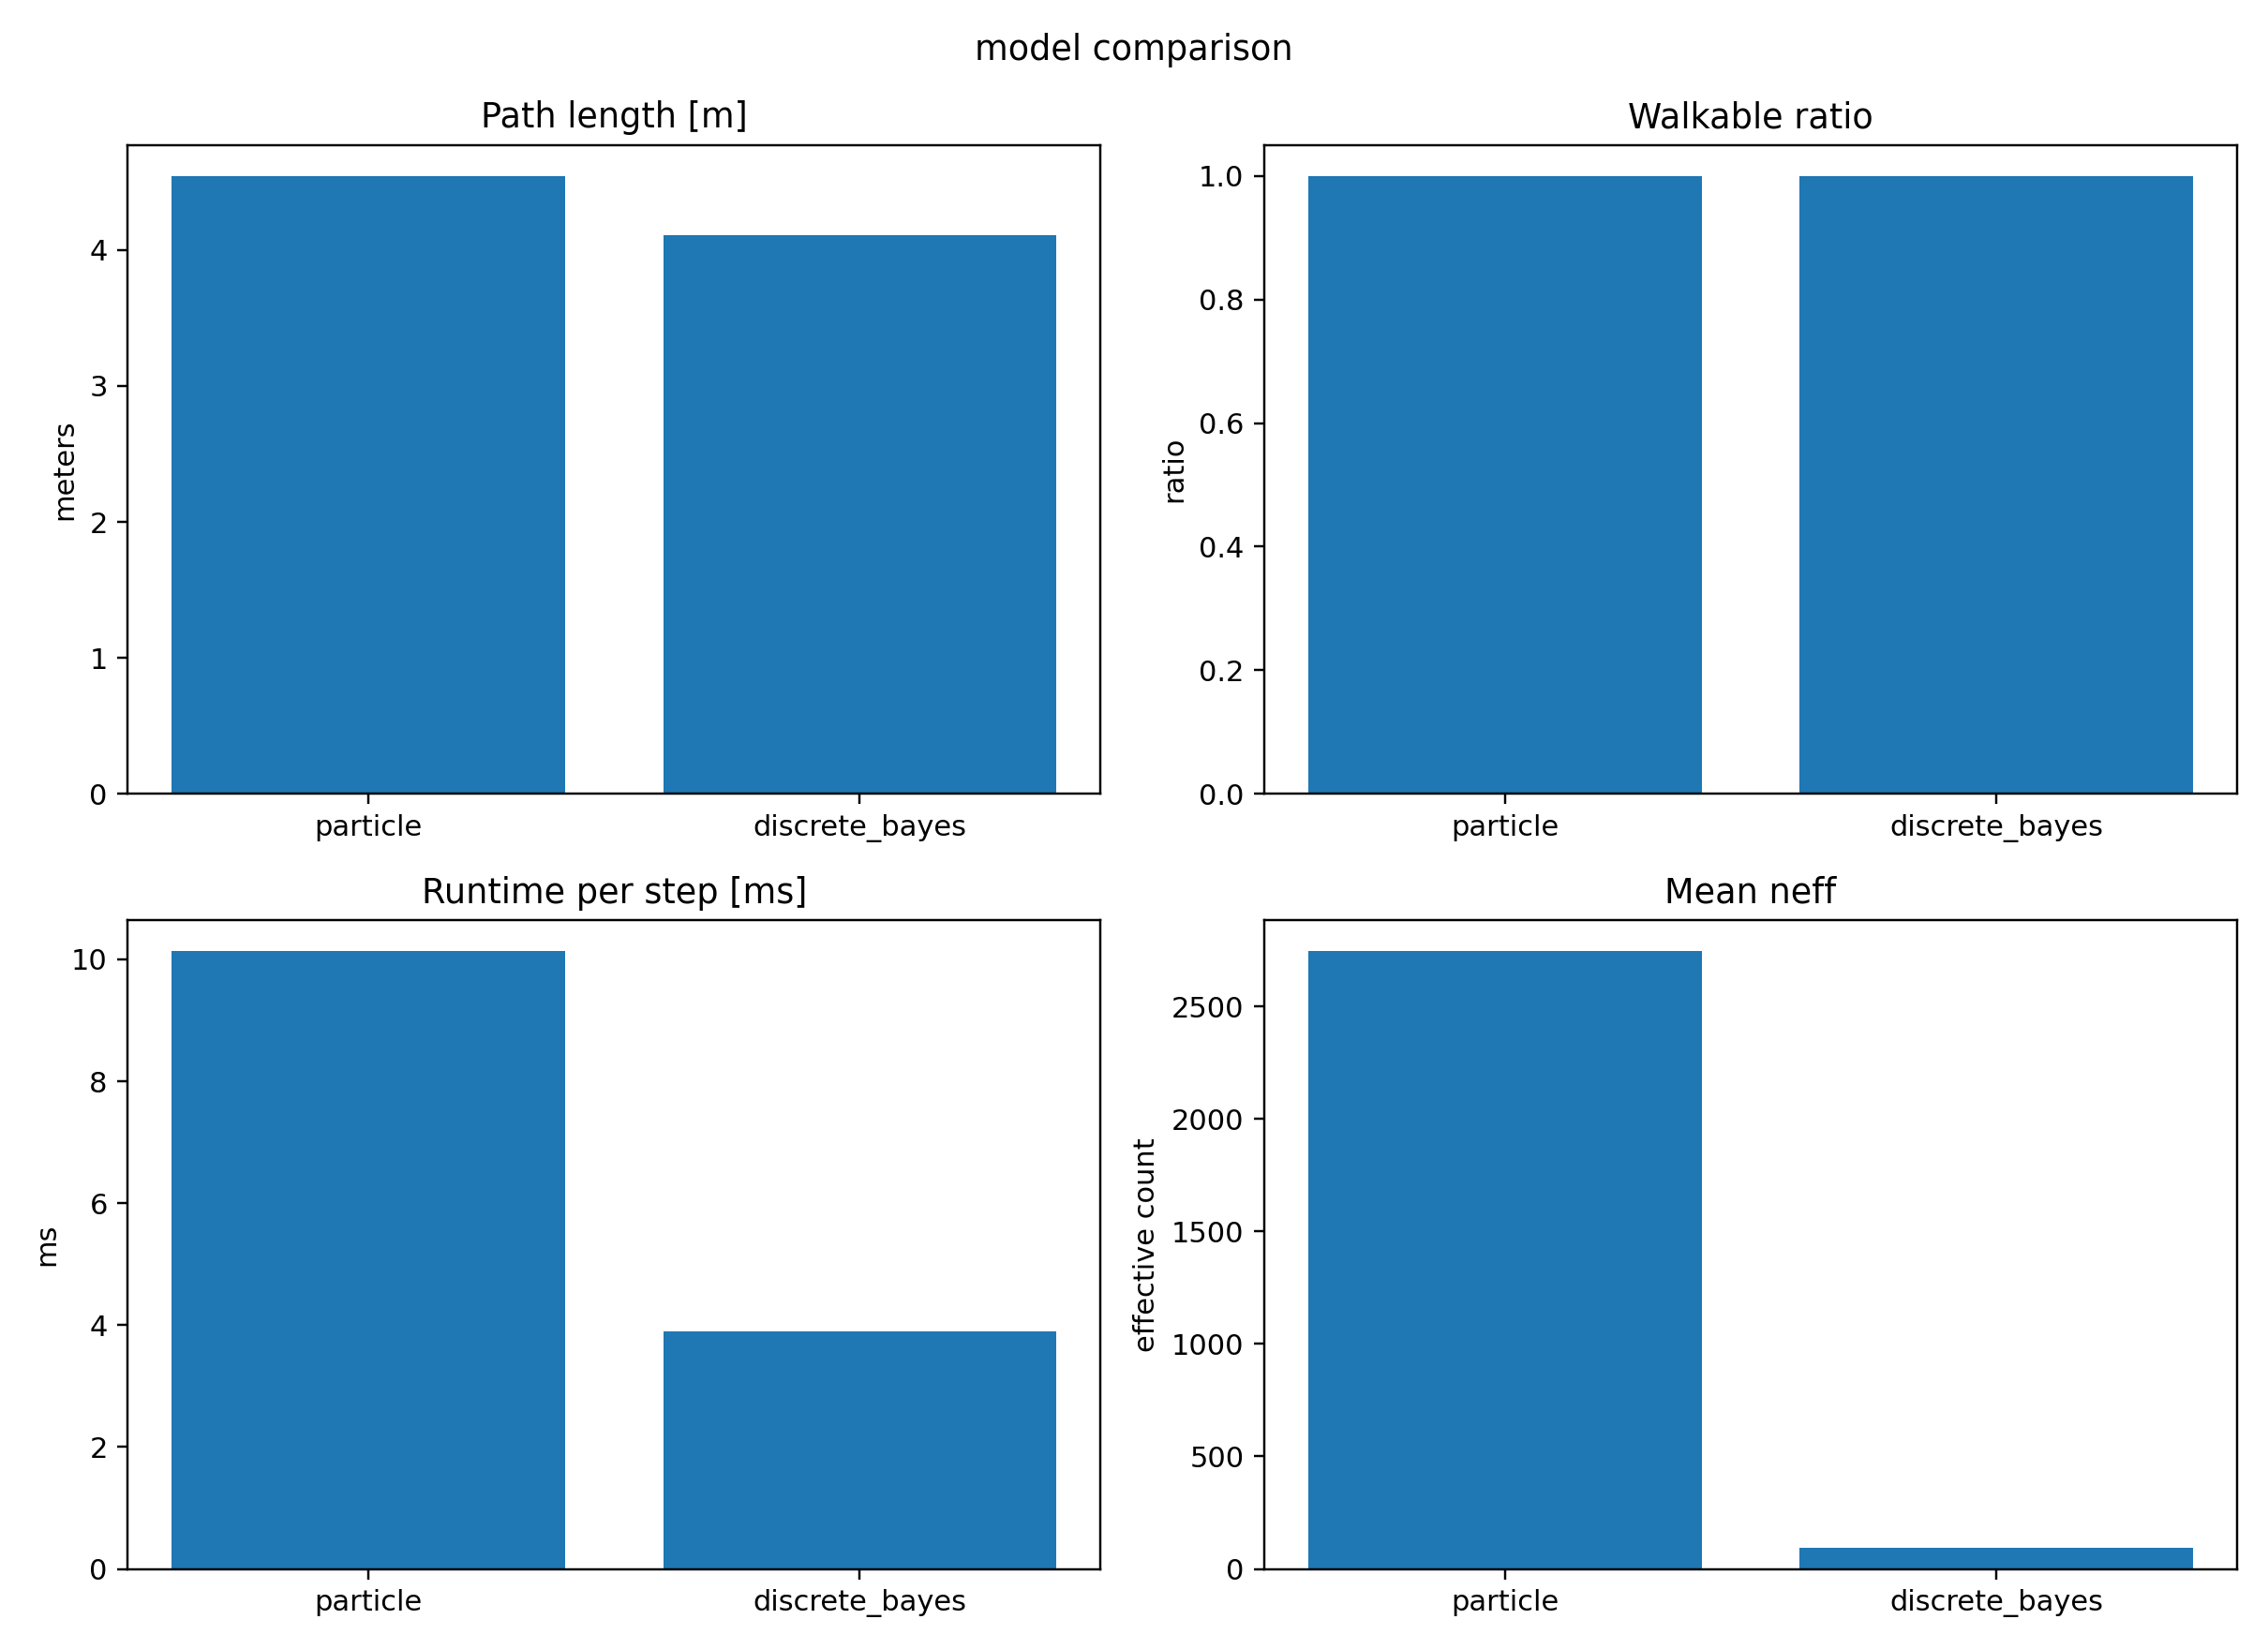

In [20]:
display(Image(filename=str(DATA / "floor_plans" / "house_floorplan_pdf.png"), width=550))
walk_plot = DATA / "experiments" / "walk" / "log_walk1_comparison.png"
if walk_plot.exists():
    display(Image(filename=str(walk_plot), width=700))

## 5. Linear Kalman filter

The assignment explicitly requires at least one linear Kalman filter. In this project, that requirement is addressed by `src/analysis/linear_kalman_filter.py` together with the analysis script `Analysis/run_linear_kalman.py`.

The linear Kalman filter is used here as a **sensor-level smoothing method** for raw gyroscope data. Its standard linear state-space form is:

$$
\begin{aligned}
x_k &= A x_{k-1} + w_{k-1} \\
z_k &= H x_k + v_k
\end{aligned}
$$

where $w_k$ denotes Gaussian process noise and $v_k$ denotes Gaussian measurement noise.

This filter is not used as the main indoor localization method. Instead, it is included as a preprocessing and analysis tool to reduce high-frequency sensor noise before evaluating heading drift and turning behavior. This makes it a valid and transparent use of a linear Kalman filter within the overall assignment.


In [21]:
kalman_summary

,group,run_name,duration_s,raw_gyro_z_std,kf_gyro_z_std,raw_final_yaw_change,kf_final_yaw_change
0,still,sensor_log_still1,10.043318,0.002877,0.001132,-0.284822,-0.286582
1,walk,sensor_log_walk1,13.946918,0.276807,0.087465,0.014902,-0.005268
2,shortTurn,sensor_log_short_turn1,14.081547,0.315779,0.208597,1.530645,1.549969
3,180Turn,sensor_log_turn180_1,19.248076,0.565229,0.394996,4.251548,4.182481


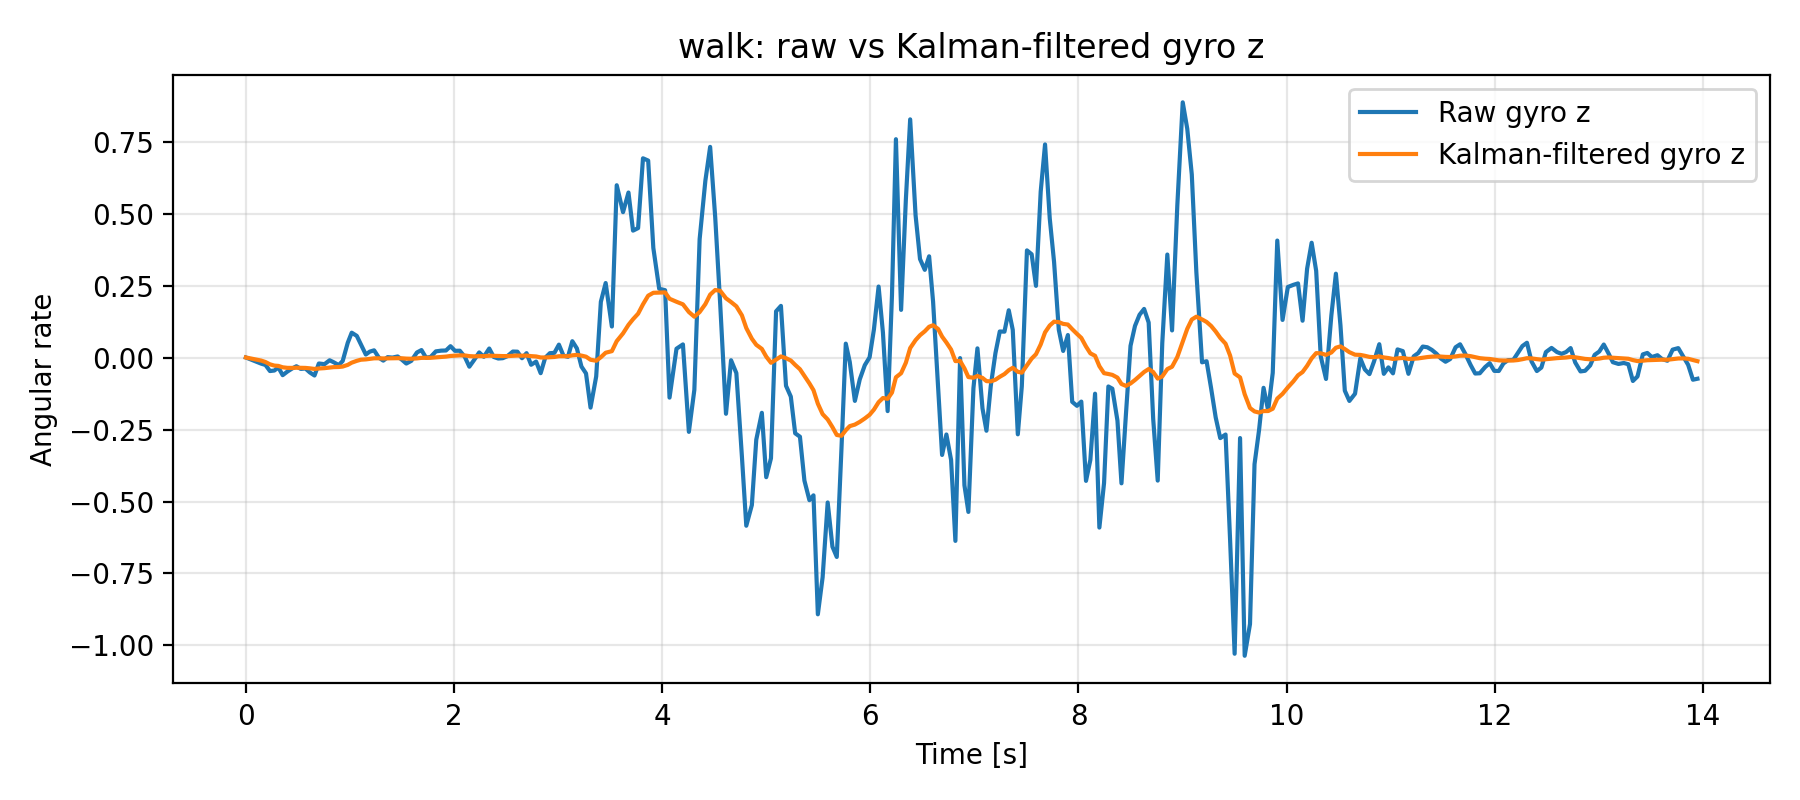

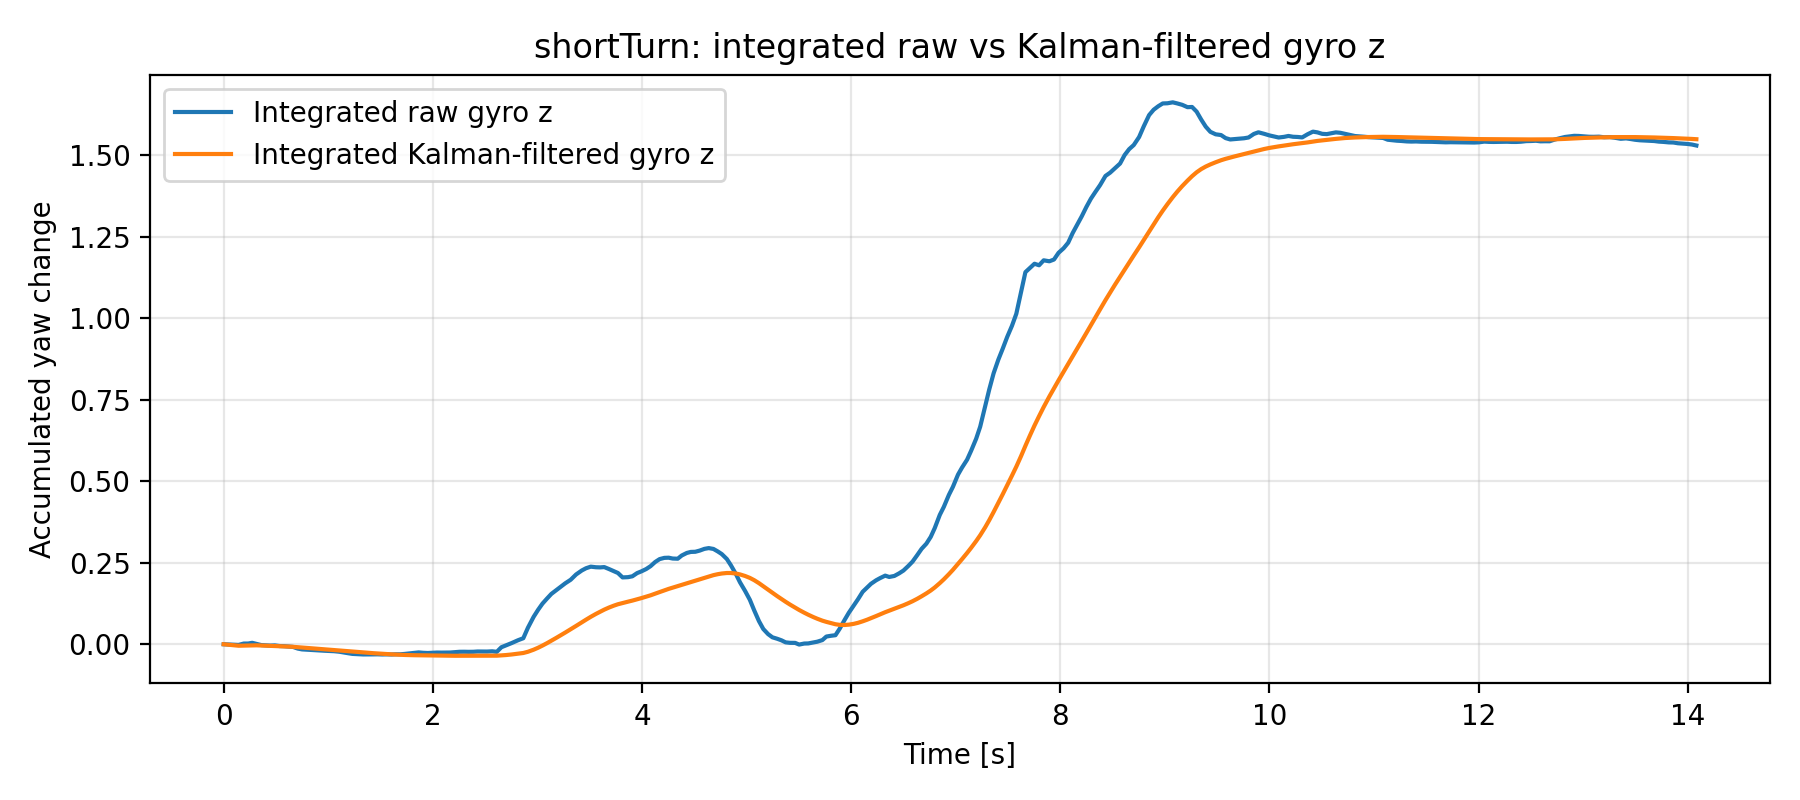

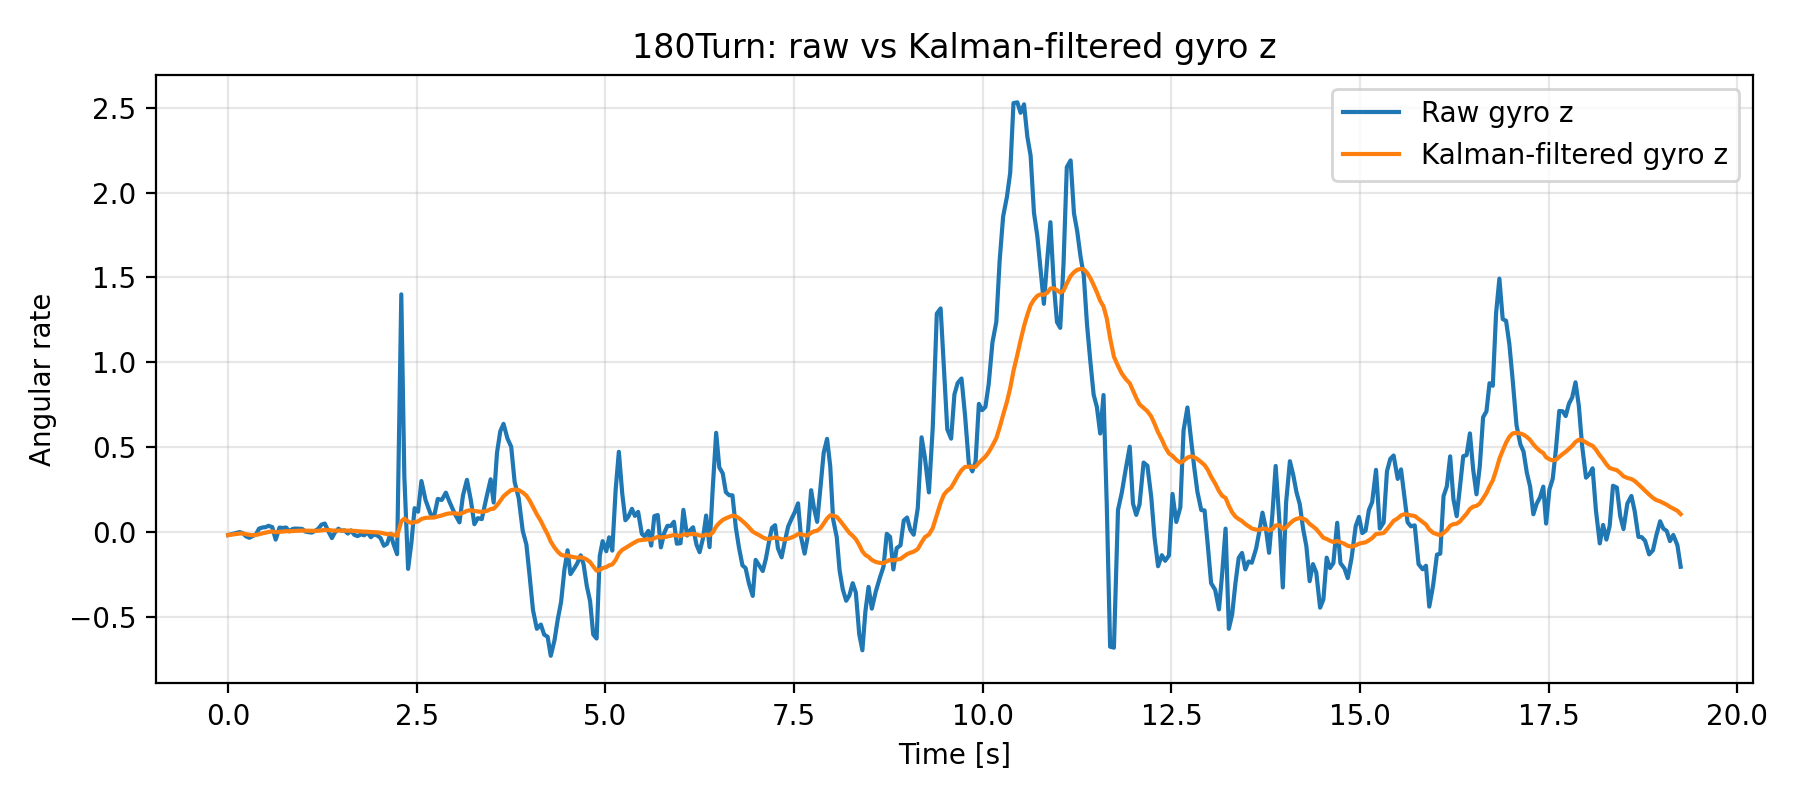

In [22]:
for name in [
    "walk_sensor_log_walk1_gyro_comparison.png",
    "shortTurn_sensor_log_short_turn1_yaw_integration.png",
    "180Turn_sensor_log_turn180_1_gyro_comparison.png",
]:
    p = OUT / "kalman_analysis" / name
    if p.exists():
        display(Image(filename=str(p), width=650))

## 6. Bayesian localization methods

### 6.1 Discrete Bayes filter

The Discrete Bayes filter is implemented in `src/imu/filters/discrete_bayes_filter.py`.

The main Bayesian update is performed in `update_step()`. In this function:

1. the previous belief is propagated through the motion model,
2. an optional stride ring is applied,
3. the prediction is multiplied by the floorplan likelihood,
4. the posterior is normalized.

Conceptually, the update follows:

$$
\begin{aligned}
p(x_k \mid Z_k) \propto p(x_k \mid \text{map}) \; p(x_k \mid d_k, x_{k-1}) \; p(x_k \mid x_{k-1}, \Delta \psi_k)
\end{aligned}
$$

where:

- `p(x_k \mid \text{map})` is the static floorplan PDF,
- `p(x_k \mid d_k, x_{k-1})` is represented by the stride ring,
- `p(x_k \mid x_{k-1}, \Delta \psi_k)` is the motion update over position and heading.

### 6.2 Particle filter

The Particle filter is implemented in `src/imu/filters/particle_filter.py`.

Its Bayesian logic is mainly implemented in `update_step()` and `_weight_from_map()`. The particles are first propagated using noisy heading and step-length updates, and are then reweighted using the floorplan probability:

$$
\begin{aligned}
w_k^{(i)} \propto w_{k-1}^{(i)} \; p(z_k \mid x_k^{(i)})
\end{aligned}
$$

In this implementation, the likelihood term is largely driven by the floorplan PDF, so particles that end up in invalid regions receive very small weights. The effective sample size is computed as:

$$
\begin{aligned}
N_{\text{eff}} = \frac{1}{\sum_i \left(w_k^{(i)}\right)^2}
\end{aligned}
$$

This quantity is used to determine when resampling is needed.

### 6.3 Where the Bayesian rules are implemented in the code

- **Discrete Bayes**: `DiscreteBayesFilter.update_step()` and `_normalize()`
- **Particle filter**: `ParticleFilter.update_step()`, `_weight_from_map()`, `neff`, and `_resample()`
- **Experiment runner**: `src/main.py`, which feeds the same step-event stream into both filters and saves comparable outputs

In [25]:
def show_snippet(path, start, end):
    lines = path.read_text(encoding="utf-8").splitlines()
    snippet = "\n".join(f"{i+1:>4}: {lines[i]}" for i in range(start-1, end))
    display(Markdown(f"```python\n{snippet}\n```"))

show_snippet(SRC / "imu" / "filters" / "discrete_bayes_filter.py", 44, 91)
show_snippet(SRC / "imu" / "filters" / "particle_filter.py", 31, 76)

```python
  44:         ih0 = int(np.argmin(np.abs(self._angle_diff(self.hs, h_init))))
  45: 
  46:         self.belief[iy0, ix0, ih0] = 1.0
  47:         self._normalize()
  48: 
  49:     def update_step(self, heading_change: float, step_length_m: float, dt: float = 1.0) -> dict:
  50:         predicted = np.zeros_like(self.belief)
  51:         spread_offsets = np.arange(-self.transition_spread_cells, self.transition_spread_cells + 1)
  52:         step_kernel = np.exp(-0.5 * (spread_offsets / max(self.transition_spread_cells, 1)) ** 2)
  53:         step_kernel /= step_kernel.sum()
  54: 
  55:         prev_mean, _, _ = self.estimate()
  56:         prior_nonzero = np.argwhere(self.belief > 1.0e-12)
  57: 
  58:         for iy, ix, ih in prior_nonzero:
  59:             p = self.belief[iy, ix, ih]
  60:             persistence_pull = np.random.normal(0.0, self.forward_bias_std)
  61:             effective_turn = self.turn_gain * (
  62:                 self.directional_persistence * heading_change
  63:                 + (1.0 - self.directional_persistence) * persistence_pull
  64:             )
  65:             new_h = self._wrap_angle(self.hs[ih] + effective_turn)
  66:             h_idx = int(np.argmin(np.abs(self._angle_diff(self.hs, new_h))))
  67: 
  68:             d = max(0.0, step_length_m)
  69:             x_new = self.xs[ix] + d * np.cos(new_h)
  70:             y_new = self.ys[iy] + d * np.sin(new_h)
  71: 
  72:             jx = int(np.argmin(np.abs(self.xs - x_new)))
  73:             jy = int(np.argmin(np.abs(self.ys - y_new)))
  74: 
  75:             for off_x, kx in zip(spread_offsets, step_kernel):
  76:                 for off_y, ky in zip(spread_offsets, step_kernel):
  77:                     tx = jx + off_x
  78:                     ty = jy + off_y
  79:                     if 0 <= tx < len(self.xs) and 0 <= ty < len(self.ys):
  80:                         predicted[ty, tx, h_idx] += p * kx * ky
  81: 
  82:         if self.use_stride_ring:
  83:             dist = np.sqrt((self._grid_x - prev_mean[0]) ** 2 + (self._grid_y - prev_mean[1]) ** 2)
  84:             ring = np.exp(-0.5 * ((dist - step_length_m) / max(self.stride_ring_sigma_m, 1.0e-6)) ** 2)
  85:             predicted *= ring[:, :, None]
  86: 
  87:         predicted *= self._map_likelihood[:, :, None]
  88:         self.belief = predicted
  89:         self._normalize()
  90: 
  91:         mean, var, mean_heading = self.estimate()
```

```python
  31: 
  32:         self.particles[:, 0] = self.rng.normal(x0, 0.15, size=self.N)
  33:         self.particles[:, 1] = self.rng.normal(y0, 0.15, size=self.N)
  34:         self.particles[:, 2] = self._wrap_angle(self.rng.normal(h0, 0.08, size=self.N))
  35:         self.weights.fill(1.0 / self.N)
  36:         self._weight_from_map()
  37: 
  38:     def update_step(self, heading_change: float, step_length_m: float, dt: float = 1.0) -> dict:
  39:         heading_noise = self.rng.normal(0.0, self.heading_noise_std, size=self.N)
  40:         persistence_pull = self.rng.normal(0.0, self.forward_bias_std, size=self.N)
  41: 
  42:         effective_turn = self.turn_gain * (
  43:             self.directional_persistence * heading_change
  44:             + (1.0 - self.directional_persistence) * persistence_pull
  45:         )
  46: 
  47:         self.particles[:, 2] = self._wrap_angle(self.particles[:, 2] + effective_turn + heading_noise)
  48: 
  49:         step_noise = self.rng.normal(0.0, self.step_length_std, size=self.N)
  50:         step = np.maximum(0.0, step_length_m + step_noise)
  51:         self.particles[:, 0] += step * np.cos(self.particles[:, 2])
  52:         self.particles[:, 1] += step * np.sin(self.particles[:, 2])
  53: 
  54:         self._weight_from_map()
  55: 
  56:         if self.neff < self.resample_threshold_ratio * self.N:
  57:             self._resample()
  58: 
  59:         mean, var, mean_heading = self.estimate()
  60:         return {
  61:             "position": mean,
  62:             "variance": var,
  63:             "heading_rad": mean_heading,
  64:             "neff": float(self.neff),
  65:         }
  66: 
  67:     def _weight_from_map(self):
  68:         probs = np.array([self.floor_map.get_probability(x, y) for x, y in self.particles[:, :2]], dtype=float)
  69:         probs = np.maximum(probs, self.impossible_state_penalty)
  70:         probs += 1.0e-15
  71:         self.weights *= probs
  72:         total = self.weights.sum()
  73:         if not np.isfinite(total) or total <= 0.0:
  74:             self.weights[:] = 1.0 / self.N
  75:         else:
  76:             self.weights /= total
```

## 7. Experimental results

The saved output files already contain several walk, short-turn, and 180-degree turn experiments. The main metrics used here are:

- **walkable ratio**: fraction of estimates remaining in valid floorplan regions
- **path length**: sanity check on motion behavior
- **runtime per step**: computational cost on the target architecture
- **mean effective sample size** for the Particle filter

The table below aggregates all runs that were already processed before submission.

In [23]:
final_summary

,model,n_steps,walkable_ratio,path_length_m,runtime_s,runtime_ms_per_step,mean_neff,final_x_m,final_y_m,group,run_name,summary_file
0,particle,16.0,0.93750,9.537706,0.127547,7.971681,2735.430567,4.691144,6.655170,180Turn,log_turn180_1,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
1,discrete_bayes,16.0,0.93750,9.129097,0.047782,2.986375,62.437500,4.417610,6.389986,180Turn,log_turn180_1,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
2,particle,11.0,1.00000,6.477968,0.112466,10.224173,2609.731213,4.268882,4.851437,180Turn,log_turn180_2,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
3,discrete_bayes,11.0,1.00000,5.753036,0.035149,3.195364,66.909091,4.710106,5.289570,180Turn,log_turn180_2,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
4,discrete_bayes,13.5,0.96875,7.441067,0.041465,3.090869,64.673295,4.563858,5.839778,outputs,final_results_grouped,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
...,...,...,...,...,...,...,...,...,...,...,...,...
61,discrete_bayes,0.0,0.00000,0.000000,0.006058,0.000000,0.000000,NaN,NaN,still,log_still,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
62,particle,8.0,1.00000,4.545037,0.081117,10.139663,2747.984898,4.107517,1.692860,walk,log_walk1,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
63,discrete_bayes,8.0,1.00000,4.108927,0.031205,3.900563,94.375000,3.973093,2.288827,walk,log_walk1,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...
64,particle,9.0,1.00000,5.250951,0.074693,8.299267,2660.586722,4.187978,0.957205,walk,log_walk2,C:\Users\Cedric busman\PycharmProjects\DFA\DFA...


In [24]:
grouped_summary

,group,model,n_steps,walkable_ratio,path_length_m,runtime_s,runtime_ms_per_step,mean_neff,final_x_m,final_y_m
0,180Turn,discrete_bayes,13.50,0.968750,7.441067,0.041465,3.090869,64.673295,4.563858,5.839778
1,180Turn,particle,13.50,0.968750,8.007837,0.120006,9.097927,2672.580890,4.480013,5.753304
2,outputs,discrete_bayes,6.75,0.742188,3.527919,0.022296,2.374624,46.506866,3.872275,4.377583
3,outputs,particle,6.75,0.710938,3.851527,0.060840,6.824409,2001.379481,3.866655,4.085687
4,shortTurn,discrete_bayes,5.00,1.000000,2.422563,0.014825,2.917000,42.333333,3.205299,5.106537
5,shortTurn,particle,5.00,0.875000,2.500275,0.043538,8.980246,2628.651224,2.972204,5.178725
6,still,discrete_bayes,0.00,0.000000,0.000000,0.003429,0.000000,0.000000,NaN,NaN
7,still,particle,0.00,0.000000,0.000000,0.001910,0.000000,0.000000,NaN,NaN
8,walk,discrete_bayes,8.50,1.000000,4.248044,0.029465,3.490626,79.020833,3.847667,2.186434
9,walk,particle,8.50,1.000000,4.897994,0.077905,9.219465,2704.285810,4.147747,1.325032


### Result interpretation

Across the stored runs, the **Discrete Bayes filter** is usually faster than the **Particle filter** while still staying highly map-consistent. The Particle filter offers a richer recursive uncertainty representation, but the extra particles increase runtime per step.

That trade-off is exactly what the assignment asks us to analyze: probabilistic richness versus computational efficiency on constrained hardware.

## 8. Error propagation, priors, and likelihoods

The main uncertainty sources in this project are:

- gyroscope drift and noisy heading change estimates
- fixed step-length assumptions
- model mismatch between real walking behavior and the motion model
- imperfect floorplan alignment or initialization

### 8.1 Why the map prior matters
Without a strong floorplan prior, heading errors accumulate and the trajectory drifts into implausible space. With the floorplan prior active, unlikely regions are suppressed and the trajectory is pushed back toward walkable areas.

### 8.2 Why motion-model parameters matter
The motion model uses parameters such as:

- `heading_noise_std_rad`
- `step_length_std_m`
- `directional_persistence`
- `forward_bias_std_rad`

These control how quickly uncertainty spreads. If heading uncertainty is made too large, the posterior becomes more diffuse and map constraints dominate. If it is made too small, the filter can become overconfident in wrong heading changes.

### 8.3 What the current experiments show
The grouped results indicate that map consistency remains high on the straight and short-turn runs, while the 180-degree turn cases are more challenging. That is expected because large turns amplify heading uncertainty and expose weaknesses in simple dead-reckoning assumptions.

In [18]:
analysis_md = (OUT / "final_results_analysis.md").read_text(encoding="utf-8")
display(Markdown(analysis_md))

# Final Results Summary

## Overall interpretation

### 180Turn
- Higher mean walkable ratio: **discrete_bayes** (0.969 vs 0.969).
- Runtime per step: discrete_bayes **3.09 ms**, particle **9.10 ms**.

### outputs
- Higher mean walkable ratio: **discrete_bayes** (0.742 vs 0.711).
- Runtime per step: discrete_bayes **2.37 ms**, particle **6.82 ms**.

### shortTurn
- Higher mean walkable ratio: **discrete_bayes** (1.000 vs 0.875).
- Runtime per step: discrete_bayes **2.92 ms**, particle **8.98 ms**.

### still
- Higher mean walkable ratio: **discrete_bayes** (0.000 vs 0.000).
- Runtime per step: discrete_bayes **0.00 ms**, particle **0.00 ms**.

### walk
- Higher mean walkable ratio: **discrete_bayes** (1.000 vs 1.000).
- Runtime per step: discrete_bayes **3.49 ms**, particle **9.22 ms**.

## Best model per run

```text
    group              run_name          model  walkable_ratio  path_length_m  runtime_ms_per_step
  180Turn         log_turn180_1 discrete_bayes          0.9375       9.129097             2.986375
  180Turn         log_turn180_2 discrete_bayes          1.0000       5.753036             3.195364
  outputs         final_results discrete_bayes          1.0000       1.866339             2.677250
  outputs final_results_grouped discrete_bayes          1.0000       2.422563             2.917000
shortTurn       log_short_turn1 discrete_bayes          1.0000       2.978787             3.156750
shortTurn       log_short_turn2 discrete_bayes          1.0000       1.866339             2.677250
    still             log_still       particle          0.0000       0.000000             0.000000
    still            log_still2       particle          0.0000       0.000000             0.000000
     walk             log_walk1 discrete_bayes          1.0000       4.108927             3.900563
     walk             log_walk2 discrete_bayes          1.0000       4.387162             3.080689
```

## Notes

- Still runs should be used mainly for noise / false-step / bias checks, not as trajectory-performance cases.
- Walk runs are the main baseline for step-length and stability.
- Short-turn / walk-turn runs are the most informative for heading behavior and corner handling.
- 180-turn runs are strongest as limitation or challenge cases, not as primary performance figures.

## 9. Interfaces and configuration management

The important runtime parameters are stored in YAML configuration files rather than hard-coded inside the experimental notebook:

- `config/system_config.yaml` for IMU experiments
- `config/dsms_config.yaml` for the MQTT programs

This improves the interface-management score because a user can change:

- the selected filter
- initial state
- motion noise parameters
- particle count
- grid resolution
- experiment output paths

without modifying the filter source code itself.

## 10. Limitations

This work still has practical limitations, and it is better to state them clearly:

1. There is **no external centimeter-accurate ground truth system** such as motion capture or UWB.
2. Step length is modeled in a simplified way.
3. The Discrete Bayes implementation uses a compact grid and therefore trades resolution for speed.
4. The Particle filter depends strongly on the chosen particle count and motion-noise settings.

Because of these limitations, the evaluation focuses on map consistency, runtime, and qualitative plausibility rather than claiming exact absolute localization accuracy.

## 11. Conclusion

The final resit submission now contains a cleaner and more defensible IMU package:

- the floorplan is used as a real probabilistic spatial constraint,
- the Bayesian update is implemented in dedicated filter classes,
- the Particle filter is compared directly against the Discrete Bayes filter,
- a linear Kalman filter is included for the required sensor-level analysis,
- the output is summarized in saved CSV tables and plots.

Overall, the Discrete Bayes filter gives the best balance between runtime and floorplan consistency on the available experiments, while the Particle filter remains the more flexible recursive Bayesian baseline.